# W8 — Mutation Tree Topology

W7 used an "event-based" tree, with one node per infection event. That means every infection event that carries no new mutation still gets its own node, making the tree unnecessarily large from a genotype point of view.

This week introduces a tree collapsed down to **mutation states (haplotypes)** (`build_infection_seq_tree`), and turns W7's inline FASTA-export/IQ-TREE code into reusable functions (`export_fasta_from_G`, `infer_tree_jc69`, `plot_phylo_tree`).

In [ ]:
import sys
import os
sys.path.append("../intervention_search")

import covasim as cv

from simulation.runner import run_evo_simulation

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


## 1) Simulation setup

Same setup as W7 (`pop_size=3000`, `n_days=60`, same `evo_pars`/`policy`), so that changing only the tree-construction method makes for a clean comparison.

In [ ]:
sim_pars = dict(
    pop_size=3000,
    pop_type='hybrid',
    pop_infected=5,
    n_days=60,
    rand_seed=1,
    beta=0.1, 
    verbose=0,    
)

evo_pars = dict(
  enable=True,
  reference="/home/jhkim/covasim_project/covasim4wastewater/docs/tutorials/sars-2-data/NC_045512_Hu-1.fasta",
  mol_clock_rate=0.000001,
  sub_model="JC",
  fitness_data_path="/home/jhkim/covasim_project/covasim4wastewater/data/nt_fitness.csv",
  store_infection_log=True,
) 

policy = dict(
    p_test=0.2,
    p_seq=0.5,
    detection_threshold=3,
    delay_pmf=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03],
    quiet_period=0,
)

## 2) Run the simulation

Same as W7: observation and evolution tracking only, no intervention.

In [ ]:
sim, obs, interv, _, results = run_evo_simulation(sim_pars, evo_pars, policy)

## 3) Event-based tree (W7's approach, for comparison)

Build the same event-based tree as W7 — this is the baseline we'll compare the haplotype-based tree against, in terms of node/edge count.

In [ ]:
from analysis.mutation_tree import build_mutation_tree, build_infection_seq_tree, mutation_tree_to_newick, extract_sequenced_subtree, export_fasta_from_G, infer_tree_jc69
from plotting.plot_mutation_tree import plot_mutation_tree, plot_erase_mutation_tree, plot_phylo_tree

In [ ]:
FIG_DIR = "../intervention_search/results/figures"

In [ ]:
sequenced_agents = set()
for day_list in obs.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_erase_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

## 4) Haplotype-based tree (this week's core idea)

`build_infection_seq_tree()` uses nodes that represent "a unique mutation state," not "an infection event." Multiple infection events sharing the same genotype collapse into one node; a new node/edge only appears when a new mutation shows up.

Compare the printed node/edge counts against the event-based tree above — this one should be much smaller. It's closer to "how many genotypically distinct lineages actually exist."

In [ ]:
G_infect, mutation_nodes, node_events = build_infection_seq_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G_infect.nodes)}, edges={len(G_infect.edges)}")

plot_erase_mutation_tree(
    G_infect,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

## 5) Keep only the sequenced lineage

Prune away branches that don't lead to a sequenced event (i.e., anything we couldn't actually observe). Every step from here on works on this pruned tree (`G_prune`) — comparisons should only be made against what's actually "observable."

Policy B mutation tree: nodes=5541, edges=5540


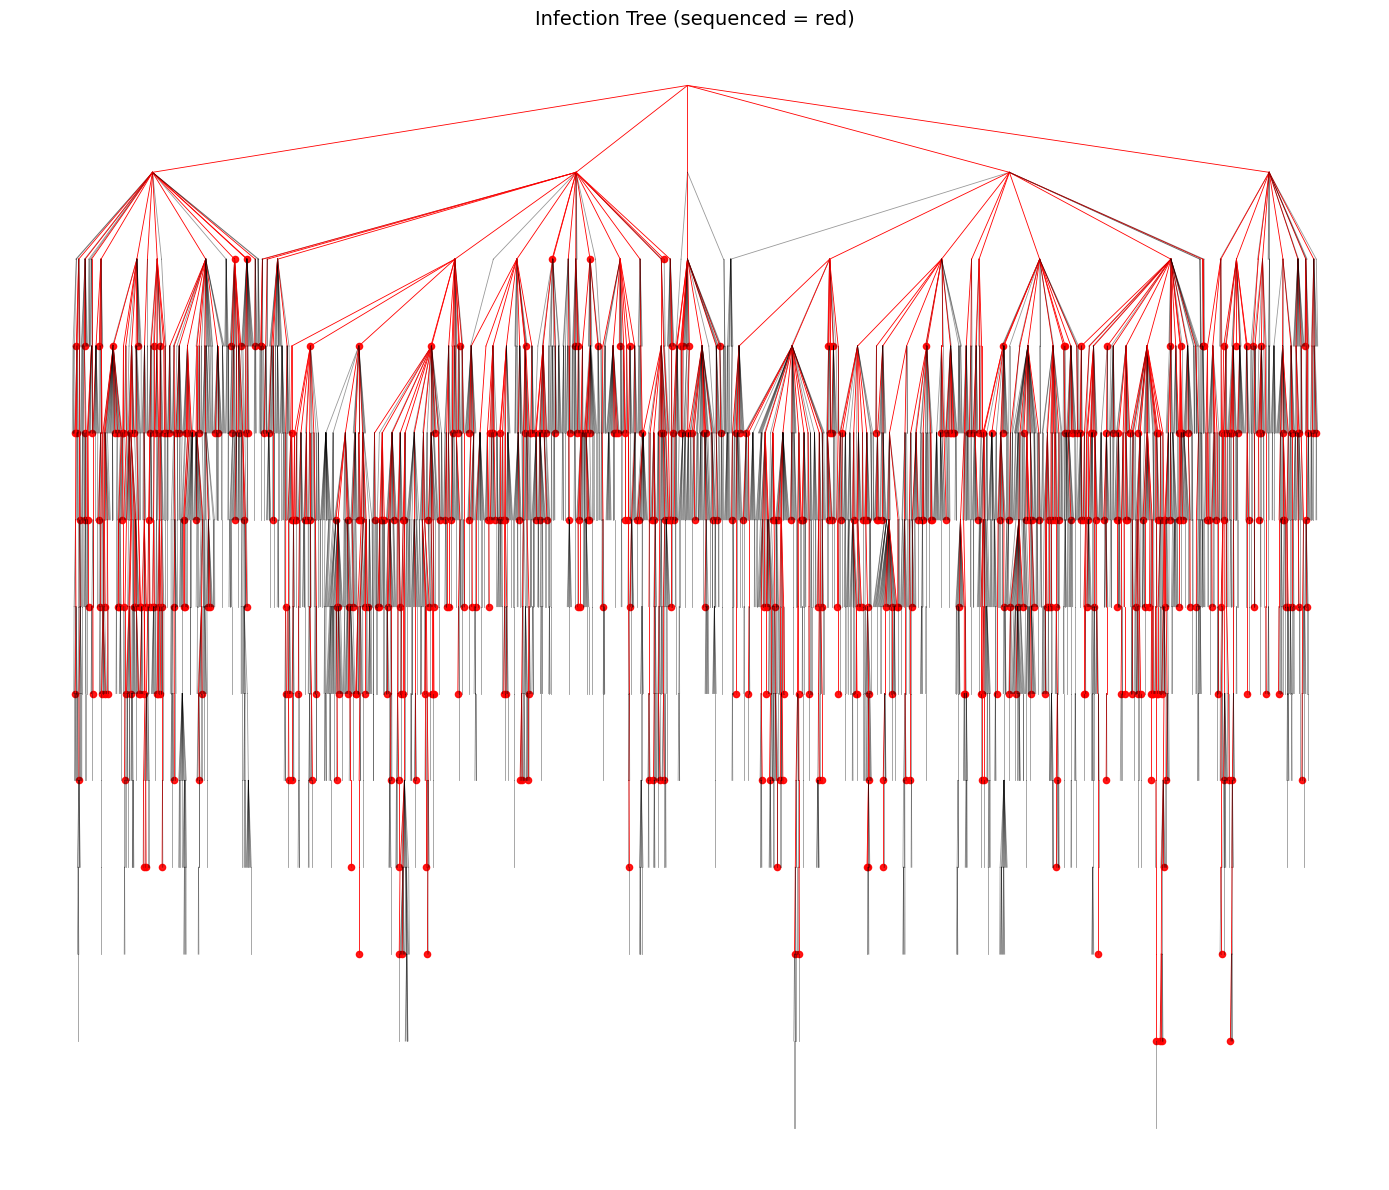

Policy B mutation tree: nodes=1020, edges=1019


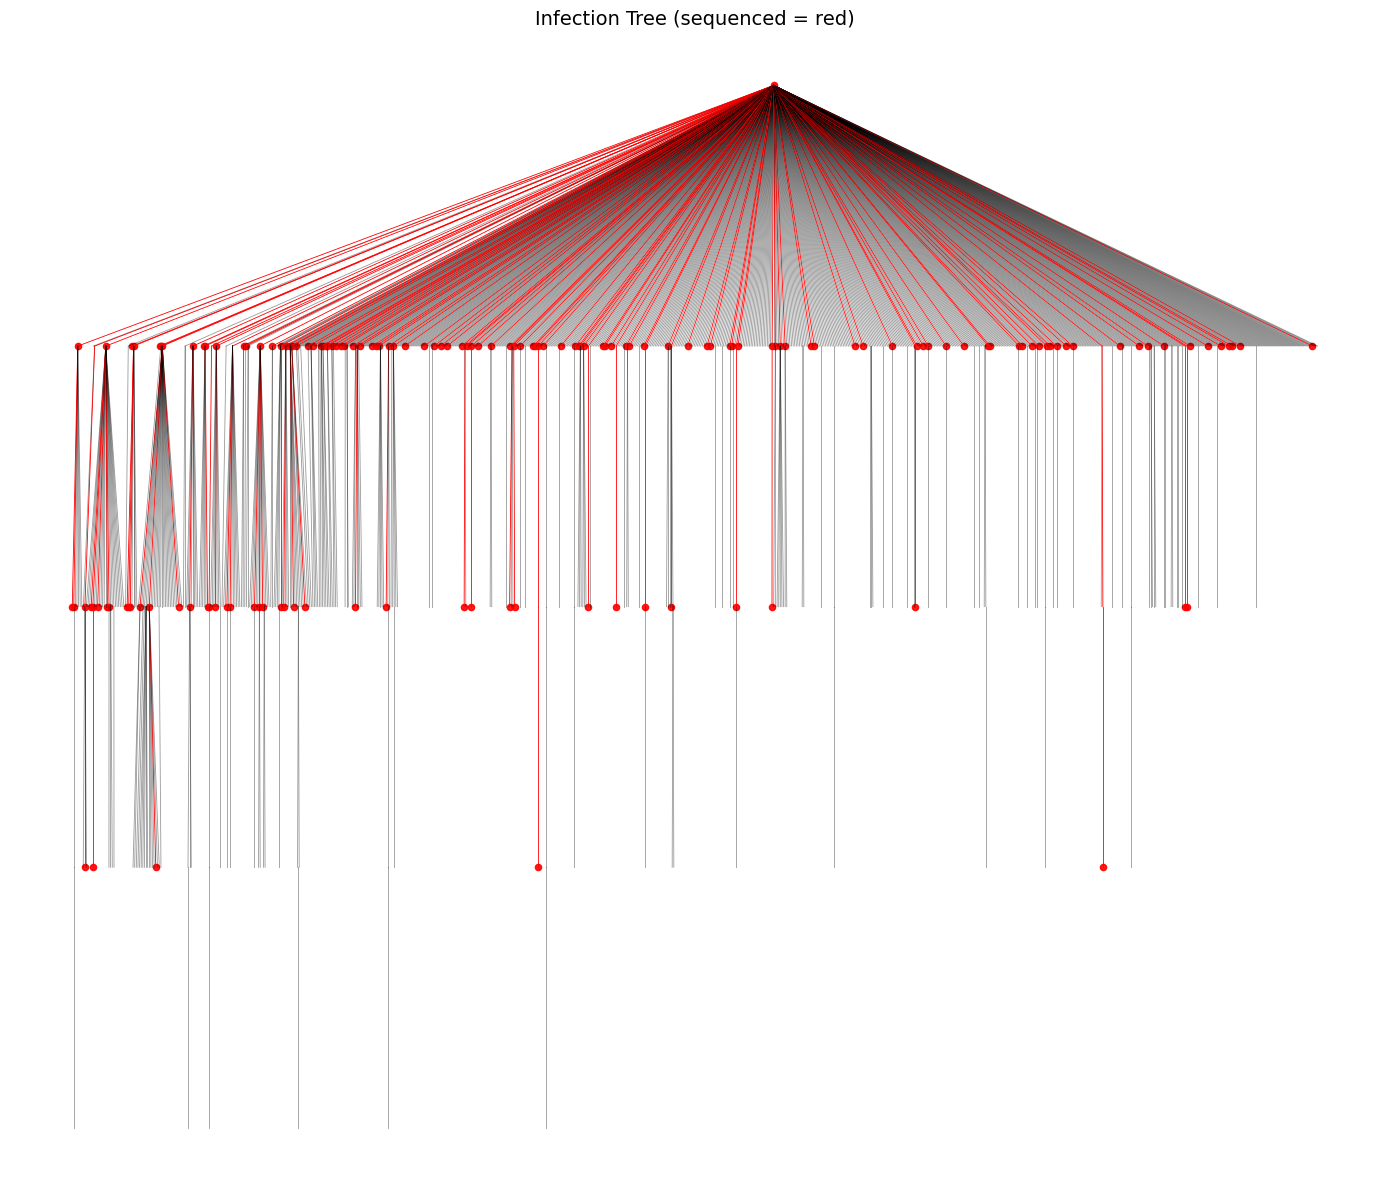

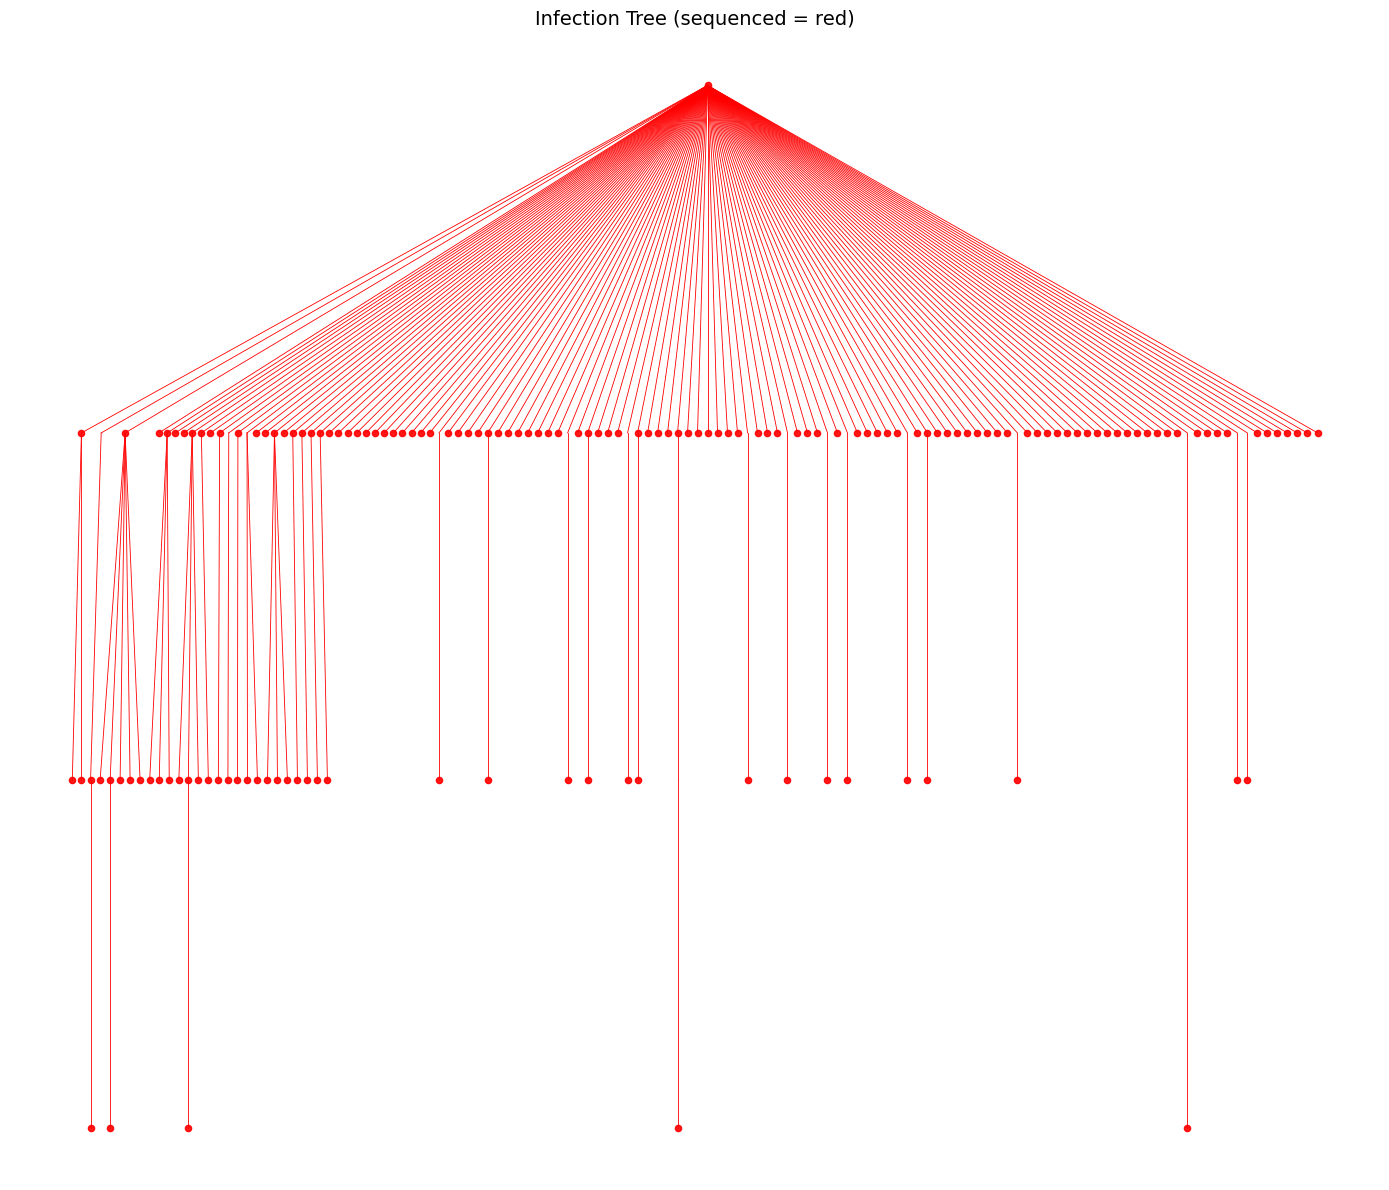

In [ ]:
G_prune = extract_sequenced_subtree(G_infect)

plot_erase_mutation_tree(
    G_prune,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

In [ ]:
from Bio import Phylo
import matplotlib.pyplot as plt

## 6) Convert to Newick and inspect

Turn the pruned haplotype tree into a Newick string and plot it with `Bio.Phylo` — no IQ-TREE inference yet, just visualizing "the true haplotype tree we already know."

> **Note**: `mutation_tree_to_newick(G, root=...)` defaults to `root="Node_0_internal"`, but that node name only exists after running `add_internal_leaves()` (used next week, W9). This tree hasn't gone through that step, so its root is actually `"Node_0"` — calling `mutation_tree_to_newick(G_prune)` with the default will look for a node that doesn't exist and error out. **Call it as `mutation_tree_to_newick(G_prune, root="Node_0")` instead.**

In [8]:
print("Node_0 attrs:", G_prune.nodes["Node_0"])


Node_0 attrs: {'mutations': frozenset(), 'sequenced': True, 'has_seq_descendant': True}


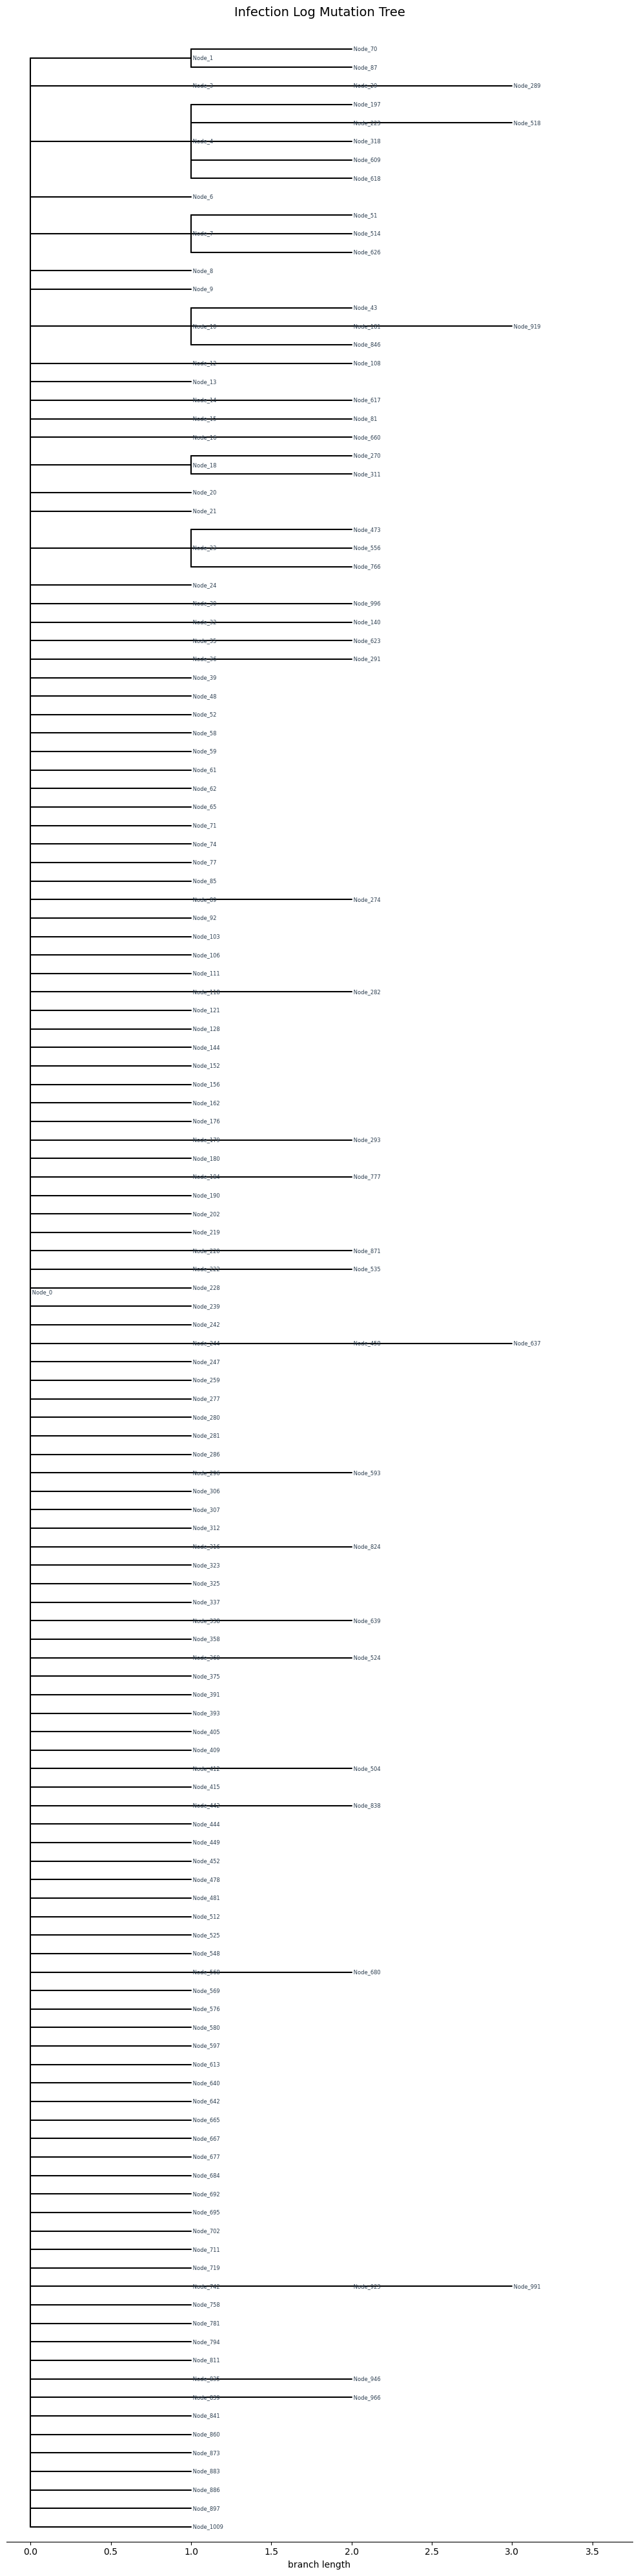

In [ ]:
newick_str = mutation_tree_to_newick(G_prune, root="Node_0")

from io import StringIO
tree = Phylo.read(StringIO(newick_str), "newick")

fig = plt.figure(figsize=(10, 40))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    # label_func=lambda x: str(x) if x.name else ""
)

for text in ax.texts:
    text.set_fontsize(6)         
    text.set_color("#2c3e50")     

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.title("Infection Log Mutation Tree", fontsize=14, pad=20)
plt.tight_layout()

plt.show()

## 7) Infer with IQ-TREE and compare

Now export FASTA from the haplotype tree (one sequence per haplotype node) and infer with IQ-TREE. Notice that the FASTA-generation, IQ-TREE run, and plotting that W7 spelled out inline are now just three function calls: `export_fasta_from_G()` -> `infer_tree_jc69()` -> `plot_phylo_tree()`.

Comparing the "true haplotype tree" from 6) against this IQ-TREE inference is this week's conclusion.

IQ-TREE version 3.1.2 for Linux x86 64-bit built May 17 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    localhost (AVX2, FMA3, 7 GB RAM)
Command: iqtree -s mutation_states.fasta -m JC69
Seed:    437637 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Fri Jul 17 16:16:00 2026
Kernel:  AVX+FMA - 1 threads (18 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 18 cores!
HINT: -nt AUTO will automatically determine the best number of threads to use.

Reading alignment file mutation_states.fasta ... Fasta format detected
Reading fasta file: done in 0.066328 secs using 85.88% CPU
Alignment most likely contains DNA/RNA sequences
Constructing alignment: done in 0.042408 secs using 83.28% CPU
Alignment has 173 sequences with 29903 columns, 195 distinct patterns
40 parsimony-in

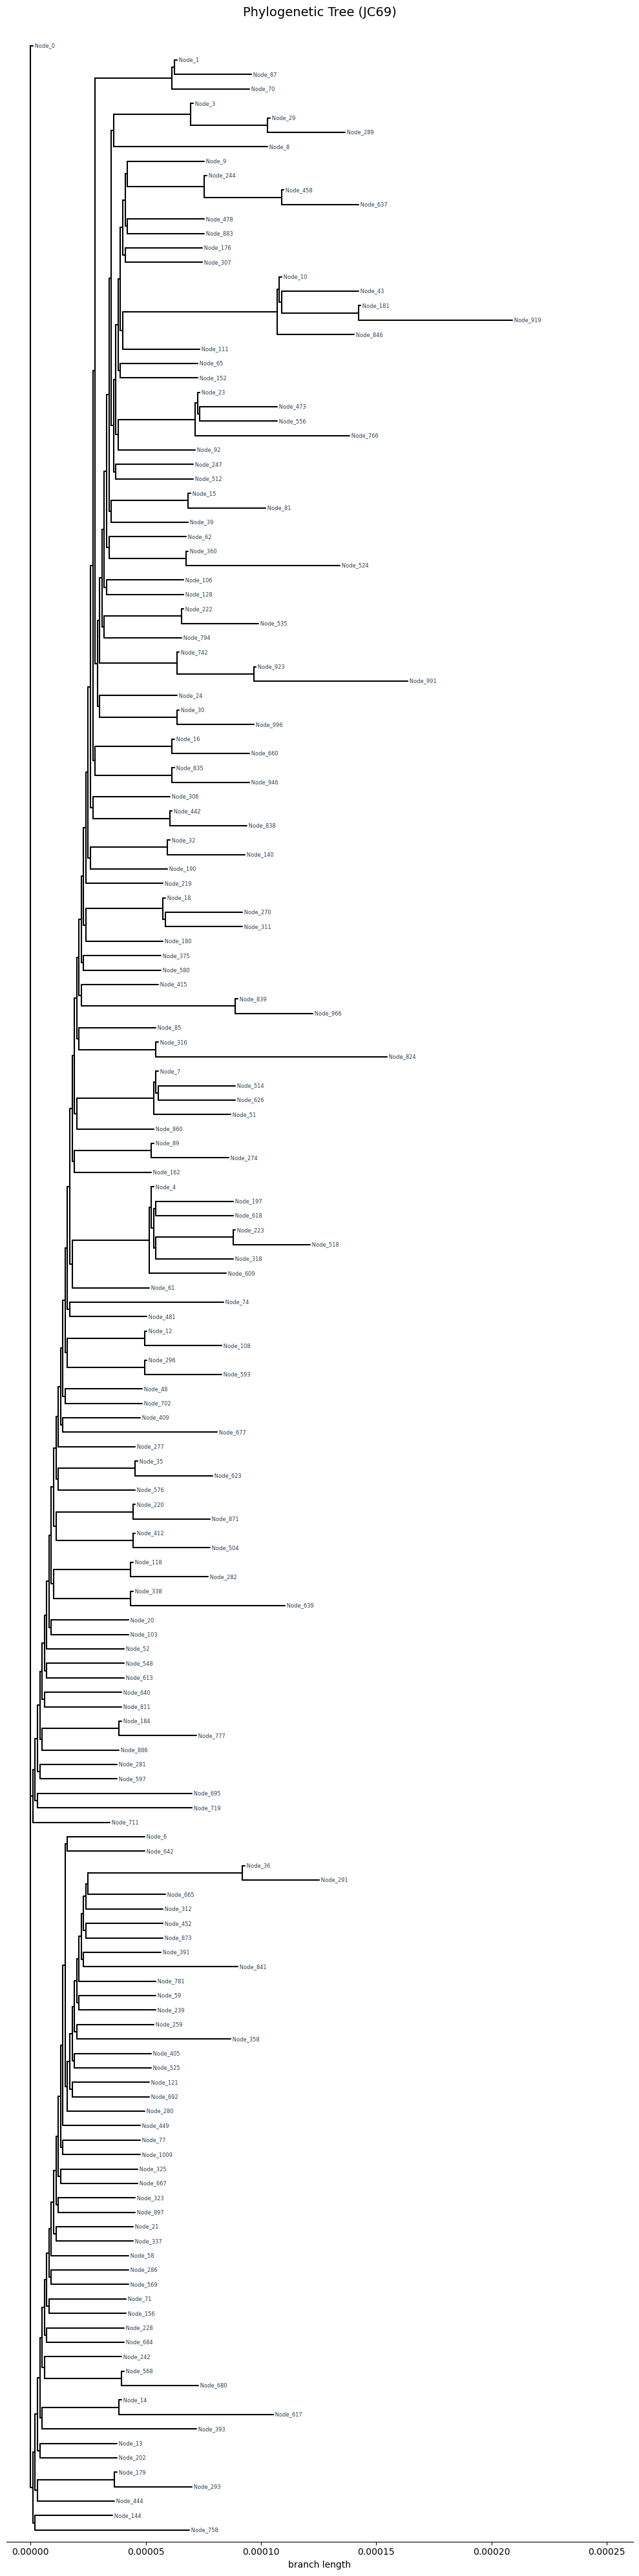

In [11]:
fasta_path = "mutation_states.fasta"
export_fasta_from_G(G_prune, sim, fasta_path)

newick_path = infer_tree_jc69(fasta_path)

plot_phylo_tree(newick_path, savepath=None)